# Regression Analysis: Theater Availability and Domestic Box Office

Research question:

**How is the number of theaters in which a movie is released associated with its domestic box office revenue, after controlling for production budget, genre, MPAA rating, release timing, and production characteristics?**

This notebook builds on the EDA notebook. The EDA showed that box office revenue and production budget are strongly skewed, so the main regression uses log-transformed variables. The focal relationship is therefore interpreted as an elasticity: how domestic box office changes, in percentage terms, when opening theater count changes.

The analysis is associational, not causal. Theater count is partly a distributor decision and may reflect unobserved expectations about demand, marketing effort, stars, reviews, or franchise value.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

REG_PATH = Path("../data/top_movies_cleaned_regression.csv")
EDA_PATH = Path("../data/top_movies_cleaned_eda.csv")

reg = pd.read_csv(REG_PATH)
eda_identifiers = pd.read_csv(EDA_PATH)

if len(reg) == len(eda_identifiers):
    df = reg.join(
        eda_identifiers[[
            "movie_name", "release_date", "opening_theaters", "max_theaters",
            "domestic_box_office_usd", "worldwide_box_office_usd", "production_budget_usd"
        ]]
    )
else:
    df = reg.copy()
    df["opening_theaters"] = np.exp(df["log_opening_theaters"])
    df["max_theaters"] = np.exp(df["log_max_theaters"])

print(f"Regression sample rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()


Regression sample rows: 4,480
Columns: 22


,log_domestic_box_office,log_worldwide_box_office,log_max_theaters,log_opening_theaters,log_budget,log_opening_weekend,release_year,release_month,running_time_minutes,is_franchise,...,source,production_method,creative_type,movie_name,release_date,opening_theaters,max_theaters,domestic_box_office_usd,worldwide_box_office_usd,production_budget_usd
0,20.657833,21.444051,8.327243,8.327243,20.094407,19.328805,2015.0,12.0,136.0,1,...,Original Screenplay,"Animation,Live Action",Science Fiction,Star Wars Ep. VII: The Force Awakens,2015-12-16,4134.0,4134.0,936662225.0,2.056047e+09,533200000
1,20.343579,21.562930,8.375860,8.343554,19.946737,18.714098,2022.0,12.0,190.0,1,...,Original Screenplay,"Animation,Live Action",Science Fiction,Avatar: The Way of Water,2022-12-09,4202.0,4340.0,684075767.0,2.315590e+09,460000000
2,18.977323,19.766057,8.434029,8.434029,19.812709,17.915971,2023.0,6.0,142.0,1,...,Original Screenplay,Live Action,Historical Fiction,Indiana Jones and the Dial of Destiny,2023-06-28,4600.0,4600.0,174480468.0,3.839631e+08,402300000
3,20.570549,21.734228,8.447414,8.447414,19.806975,19.693568,2019.0,4.0,181.0,1,...,Based on Comic/Graphic Novel,"Animation,Live Action",Super Hero,Avengers: Endgame,2019-04-23,4662.0,4662.0,858373000.0,2.748243e+09,400000000
4,19.300605,20.767966,8.334472,8.332308,19.753047,18.317007,2011.0,5.0,136.0,1,...,Based on Theme Park Ride,Live Action,Historical Fiction,Pirates of the Caribbean: On Stranger Tides,2011-05-20,4155.0,4164.0,241071802.0,1.045714e+09,379000000


## 1. Variable Preparation

The regression-ready dataset already contains the key log variables. This section prepares grouped categorical variables so rare MPAA ratings and small production categories do not create unstable one-observation dummy variables.

Main dependent variable:

- `log_domestic_box_office`

Main explanatory variable:

- `log_opening_theaters`

Primary controls:

- `log_budget`
- Genre and MPAA rating
- Release month and release year fixed effects
- Source, production method, creative type
- Franchise status and running time


In [2]:
def clean_rating(value):
    value = str(value).strip()
    if value.startswith("PG-13"):
        return "PG-13"
    if value.startswith("PG"):
        return "PG"
    if value.startswith("R"):
        return "R"
    if value.startswith("G"):
        return "G"
    if value.startswith("NC-17"):
        return "NC-17"
    return "Not Rated / Other"


def collapse_rare_categories(series, min_count=30, other_label="Other"):
    counts = series.value_counts(dropna=False)
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other_label)

model_data = df.copy()
model_data["release_year"] = model_data["release_year"].astype(int)
model_data["release_month"] = model_data["release_month"].astype(int)
model_data["release_quarter"] = ((model_data["release_month"] - 1) // 3 + 1).astype(int)
model_data["rating_group"] = model_data["mpaa_rating"].apply(clean_rating)
model_data["genre_grouped"] = collapse_rare_categories(model_data["genre"], min_count=40)
model_data["source_grouped"] = collapse_rare_categories(model_data["source"], min_count=50)
model_data["production_method_grouped"] = collapse_rare_categories(model_data["production_method"], min_count=40)
model_data["creative_type_grouped"] = collapse_rare_categories(model_data["creative_type"], min_count=40)
model_data["franchise_label"] = model_data["is_franchise"].map({0: "Standalone", 1: "Franchise"})
model_data["log_budget_centered"] = model_data["log_budget"] - model_data["log_budget"].mean()

required = [
    "log_domestic_box_office", "log_opening_theaters", "log_budget",
    "release_year", "release_month", "running_time_minutes", "is_franchise",
    "rating_group", "genre_grouped", "source_grouped",
    "production_method_grouped", "creative_type_grouped"
]

missing_summary = model_data[required].isna().sum().to_frame("missing")
missing_summary


,missing
log_domestic_box_office,0
log_opening_theaters,0
log_budget,0
release_year,0
release_month,0
running_time_minutes,0
is_franchise,0
rating_group,0
genre_grouped,0
source_grouped,0


In [3]:
category_counts = {
    "rating_group": model_data["rating_group"].value_counts(),
    "genre_grouped": model_data["genre_grouped"].value_counts(),
    "source_grouped": model_data["source_grouped"].value_counts(),
    "production_method_grouped": model_data["production_method_grouped"].value_counts(),
    "creative_type_grouped": model_data["creative_type_grouped"].value_counts(),
}

for name, counts in category_counts.items():
    print()
    print(name)
    print(counts.to_string())



rating_group
rating_group
R                    1943
PG-13                1612
PG                    689
Not Rated / Other     144
G                      86
NC-17                   6

genre_grouped
genre_grouped
Drama                1150
Comedy                739
Action                649
Adventure             576
Thriller/Suspense     479
Horror                381
Romantic Comedy       223
Black Comedy           99
Musical                68
Documentary            60
Western                41
Other                  15

source_grouped
source_grouped
Original Screenplay                  2315
Based on Fiction Book/Short Story     841
Based on Real Life Events             346
Other                                 276
Based on Comic/Graphic Novel          188
Remake                                159
Based on TV                           148
Based on Factual Book/Article         145
Based on Play                          62

production_method_grouped
production_method_grouped
Live Action   

## 2. Regression Sample Description

The EDA established that raw revenue variables are highly skewed. This table focuses on the variables used directly in the regression model and confirms the analytic sample size.


In [4]:
def compact_usd(x):
    if pd.isna(x):
        return ""
    if abs(x) >= 1_000_000_000:
        return f"${x / 1_000_000_000:,.2f}B"
    if abs(x) >= 1_000_000:
        return f"${x / 1_000_000:,.1f}M"
    if abs(x) >= 1_000:
        return f"${x / 1_000:,.1f}K"
    return f"${x:,.0f}"

sample_summary_vars = [
    "log_domestic_box_office", "log_opening_theaters", "log_budget",
    "opening_theaters", "domestic_box_office_usd", "production_budget_usd",
    "running_time_minutes", "release_year", "is_franchise"
]

sample_summary = model_data[sample_summary_vars].describe(percentiles=[.05, .25, .5, .75, .95]).T
sample_summary[["count", "mean", "std", "min", "5%", "25%", "50%", "75%", "95%", "max"]]


,count,mean,std,min,5%,25%,50%,75%,95%,max
log_domestic_box_office,4480.0,1.670696e+01,2.107885e+00,5.579730,1.223233e+01,1.587633e+01,1.724609e+01,1.807991e+01,1.915578e+01,2.065783e+01
log_opening_theaters,4480.0,6.196295e+00,2.635456e+00,0.693147,1.098612e+00,3.688879e+00,7.743920e+00,8.025189e+00,8.287352e+00,8.462948e+00
log_budget,4480.0,1.687139e+01,1.411312e+00,8.699681,1.422098e+01,1.611810e+01,1.703439e+01,1.782284e+01,1.882615e+01,2.009441e+01
opening_theaters,4480.0,1.906879e+03,1.425347e+03,1.000000,2.000000e+00,3.900000e+01,2.306500e+03,3.056000e+03,3.972300e+03,4.735000e+03
domestic_box_office_usd,4480.0,5.764449e+07,8.317321e+07,264.000000,2.053226e+05,7.852404e+06,3.089456e+07,7.112215e+07,2.085697e+08,9.366622e+08
production_budget_usd,4480.0,4.284373e+07,4.984044e+07,6000.000000,1.500000e+06,1.000000e+07,2.500000e+07,5.500000e+07,1.500000e+08,5.332000e+08
running_time_minutes,4480.0,1.095596e+02,1.865696e+01,42.000000,8.600000e+01,9.600000e+01,1.070000e+02,1.190000e+02,1.430000e+02,2.510000e+02
release_year,4480.0,2.008285e+03,8.505568e+00,1972.000000,1.994000e+03,2.003000e+03,2.009000e+03,2.015000e+03,2.021000e+03,2.025000e+03
is_franchise,4480.0,2.645089e-01,4.411206e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


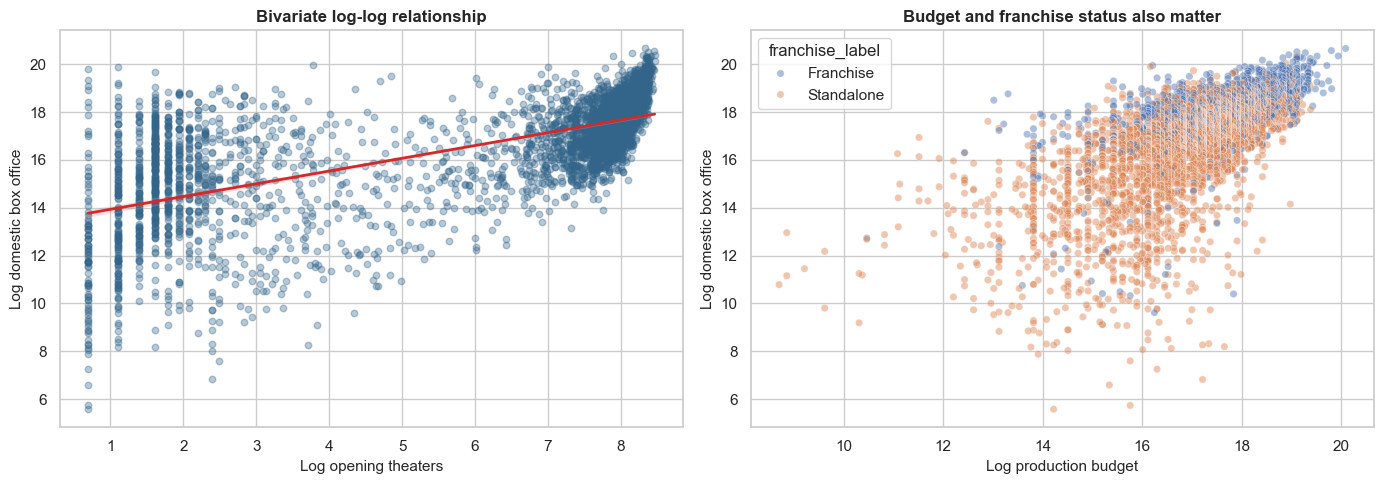

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=model_data,
    x="log_opening_theaters",
    y="log_domestic_box_office",
    scatter_kws={"alpha": 0.35, "s": 22, "color": "#33658A"},
    line_kws={"color": "#D62828", "linewidth": 2},
    ax=axes[0],
)
axes[0].set_title("Bivariate log-log relationship")
axes[0].set_xlabel("Log opening theaters")
axes[0].set_ylabel("Log domestic box office")

sns.scatterplot(
    data=model_data,
    x="log_budget",
    y="log_domestic_box_office",
    hue="franchise_label",
    alpha=0.45,
    s=28,
    ax=axes[1],
)
axes[1].set_title("Budget and franchise status also matter")
axes[1].set_xlabel("Log production budget")
axes[1].set_ylabel("Log domestic box office")

plt.tight_layout()
plt.show()


## 3. Model Specification

The models are estimated with OLS and HC3 robust standard errors.

Model sequence:

1. **M1 Bivariate:** theater count only.
2. **M2 Budget adjusted:** adds production budget.
3. **M3 Market controls:** adds release month, release year, MPAA rating, and genre.
4. **M4 Preferred full model:** adds production source, production method, creative type, franchise status, and running time.

The preferred model is:

`log_domestic_box_office = beta_0 + beta_1 log_opening_theaters + beta_2 log_budget + fixed effects and controls + error`


In [6]:
y = "log_domestic_box_office"
x = "log_opening_theaters"

formulas = {
    "M1: bivariate": f"{y} ~ {x}",
    "M2: + budget": f"{y} ~ {x} + log_budget",
    "M3: + timing/rating/genre": (
        f"{y} ~ {x} + log_budget + C(release_month) + C(release_year) "
        "+ C(rating_group) + C(genre_grouped)"
    ),
    "M4: preferred full": (
        f"{y} ~ {x} + log_budget + C(release_month) + C(release_year) "
        "+ C(rating_group) + C(genre_grouped) + C(source_grouped) "
        "+ C(production_method_grouped) + C(creative_type_grouped) "
        "+ is_franchise + running_time_minutes"
    ),
}

models = {
    name: smf.ols(formula, data=model_data).fit(cov_type="HC3")
    for name, formula in formulas.items()
}

print("Models fitted:")
for name, model in models.items():
    print(f"{name}: n={int(model.nobs):,}, R2={model.rsquared:.3f}")


Models fitted:
M1: bivariate: n=4,480, R2=0.445
M2: + budget: n=4,480, R2=0.535
M3: + timing/rating/genre: n=4,480, R2=0.612
M4: preferred full: n=4,480, R2=0.643


In [7]:
def p_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "."
    return ""


def model_term_table(models, term="log_opening_theaters"):
    rows = []
    for name, model in models.items():
        conf = model.conf_int().loc[term]
        beta = model.params[term]
        rows.append({
            "model": name,
            "coef": beta,
            "robust_se": model.bse[term],
            "p_value": model.pvalues[term],
            "stars": p_stars(model.pvalues[term]),
            "ci_low": conf[0],
            "ci_high": conf[1],
            "doubling_effect_pct": (2 ** beta - 1) * 100,
            "n": int(model.nobs),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
        })
    return pd.DataFrame(rows)

theater_results = model_term_table(models, x)
theater_results.round({
    "coef": 3, "robust_se": 3, "p_value": 4, "ci_low": 3, "ci_high": 3,
    "doubling_effect_pct": 1, "r_squared": 3, "adj_r_squared": 3
})


,model,coef,robust_se,p_value,stars,ci_low,ci_high,doubling_effect_pct,n,r_squared,adj_r_squared
0,M1: bivariate,0.534,0.012,0.0,***,0.510,0.558,44.7,4480,0.445,0.445
1,M2: + budget,0.353,0.014,0.0,***,0.325,0.381,27.7,4480,0.535,0.535
2,M3: + timing/rating/genre,0.339,0.015,0.0,***,0.310,0.369,26.5,4480,0.612,0.605
3,M4: preferred full,0.327,0.015,0.0,***,0.297,0.357,25.4,4480,0.643,0.635


In [8]:
comparison_rows = []
for name, model in models.items():
    comparison_rows.append({
        "model": name,
        "theater_coef": model.params[x],
        "theater_se": model.bse[x],
        "budget_coef": model.params.get("log_budget", np.nan),
        "budget_se": model.bse.get("log_budget", np.nan),
        "n": int(model.nobs),
        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
    })

model_comparison = pd.DataFrame(comparison_rows)
model_comparison.round(3)


,model,theater_coef,theater_se,budget_coef,budget_se,n,r_squared,adj_r_squared
0,M1: bivariate,0.534,0.012,NaN,NaN,4480,0.445,0.445
1,M2: + budget,0.353,0.014,0.561,0.022,4480,0.535,0.535
2,M3: + timing/rating/genre,0.339,0.015,0.507,0.026,4480,0.612,0.605
3,M4: preferred full,0.327,0.015,0.411,0.029,4480,0.643,0.635


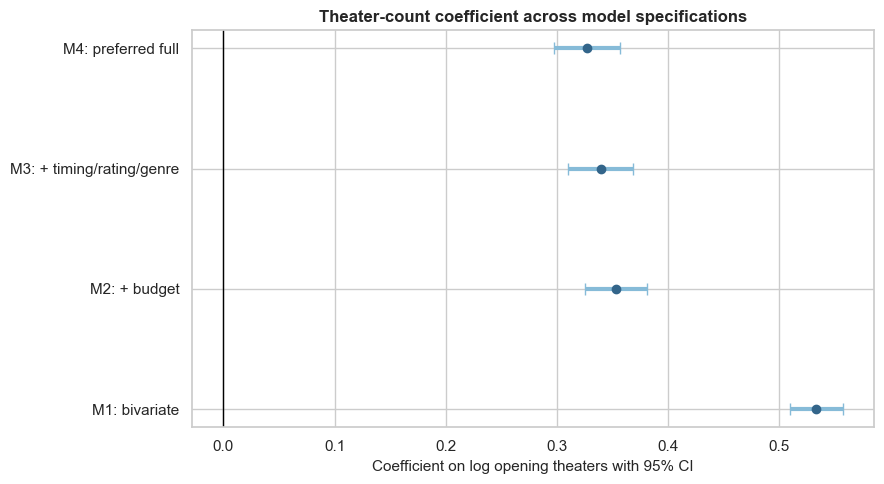

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = theater_results.copy()
plot_data["err_low"] = plot_data["coef"] - plot_data["ci_low"]
plot_data["err_high"] = plot_data["ci_high"] - plot_data["coef"]

ax.errorbar(
    x=plot_data["coef"],
    y=plot_data["model"],
    xerr=[plot_data["err_low"], plot_data["err_high"]],
    fmt="o",
    color="#33658A",
    ecolor="#86BBD8",
    elinewidth=3,
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Theater-count coefficient across model specifications")
ax.set_xlabel("Coefficient on log opening theaters with 95% CI")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 4. Preferred Model Interpretation

The preferred specification is M4. Because both the outcome and focal predictor are logged, the coefficient on `log_opening_theaters` is an elasticity.


In [10]:
preferred = models["M4: preferred full"]
preferred_beta = preferred.params[x]
preferred_se = preferred.bse[x]
preferred_p = preferred.pvalues[x]
preferred_ci = preferred.conf_int().loc[x]
preferred_doubling = (2 ** preferred_beta - 1) * 100

interpretation = f"""
### Main result

In the preferred model, the coefficient on `log_opening_theaters` is **{preferred_beta:.3f}** with an HC3 robust standard error of **{preferred_se:.3f}**.
The 95% confidence interval is **[{preferred_ci[0]:.3f}, {preferred_ci[1]:.3f}]**, and the p-value is **{preferred_p:.3g}**.

Substantively, this implies that a **doubling of opening theater count** is associated with about a **{preferred_doubling:.1f}% increase in domestic box office revenue**, holding budget, release timing, MPAA rating, genre, production characteristics, franchise status, and running time constant.

This should be interpreted as an association. It does not prove that adding theaters mechanically causes this increase, because distributors may choose wider releases for movies expected to perform well.
"""

display(Markdown(interpretation))



### Main result

In the preferred model, the coefficient on `log_opening_theaters` is **0.327** with an HC3 robust standard error of **0.015**.
The 95% confidence interval is **[0.297, 0.357]**, and the p-value is **5.32e-102**.

Substantively, this implies that a **doubling of opening theater count** is associated with about a **25.4% increase in domestic box office revenue**, holding budget, release timing, MPAA rating, genre, production characteristics, franchise status, and running time constant.

This should be interpreted as an association. It does not prove that adding theaters mechanically causes this increase, because distributors may choose wider releases for movies expected to perform well.


In [11]:
key_terms = ["log_opening_theaters", "log_budget", "is_franchise", "running_time_minutes"]
key_coef = pd.DataFrame({
    "coef": preferred.params,
    "robust_se": preferred.bse,
    "p_value": preferred.pvalues,
    "ci_low": preferred.conf_int()[0],
    "ci_high": preferred.conf_int()[1],
})
key_coef.loc[key_terms].round(4)


,coef,robust_se,p_value,ci_low,ci_high
log_opening_theaters,0.3271,0.0153,0.0,0.2972,0.3570
log_budget,0.4111,0.0287,0.0,0.3549,0.4673
is_franchise,0.7347,0.0431,0.0,0.6502,0.8192
running_time_minutes,0.0110,0.0015,0.0,0.0081,0.0139


## 5. Added-Variable View of the Main Relationship

The next plot residualizes both domestic box office and opening theater count against the full set of controls except `log_opening_theaters`. This visual asks: after removing the variation explained by budget, timing, genre, rating, and production characteristics, is there still a visible relationship between theater count and domestic revenue?


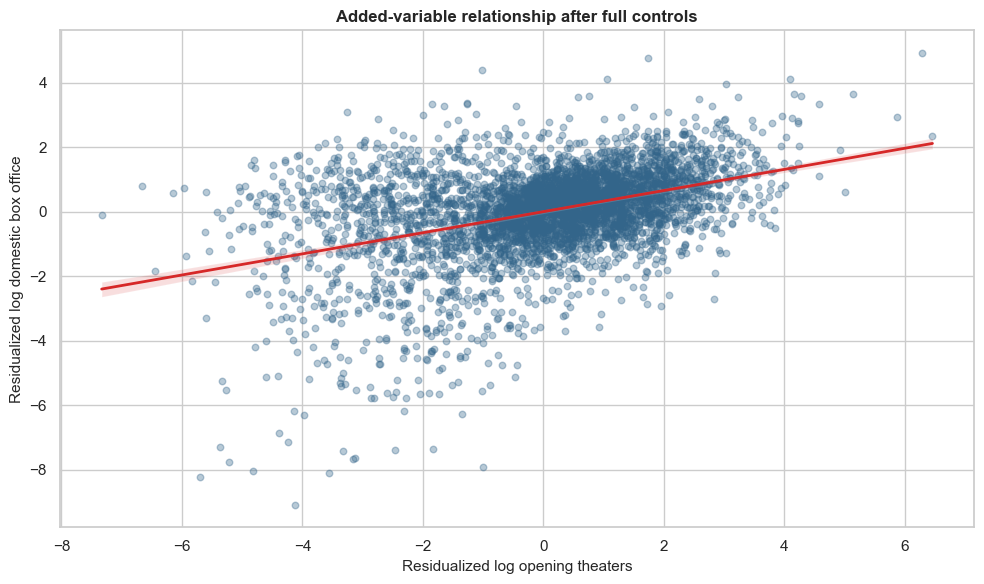

In [12]:
controls_only_formula_y = (
    f"{y} ~ log_budget + C(release_month) + C(release_year) "
    "+ C(rating_group) + C(genre_grouped) + C(source_grouped) "
    "+ C(production_method_grouped) + C(creative_type_grouped) "
    "+ is_franchise + running_time_minutes"
)
controls_only_formula_x = controls_only_formula_y.replace(y, x, 1)

resid_y = smf.ols(controls_only_formula_y, data=model_data).fit().resid
resid_x = smf.ols(controls_only_formula_x, data=model_data).fit().resid

partial_df = pd.DataFrame({
    "residual_log_domestic": resid_y,
    "residual_log_opening_theaters": resid_x,
})

sns.regplot(
    data=partial_df,
    x="residual_log_opening_theaters",
    y="residual_log_domestic",
    scatter_kws={"alpha": 0.35, "s": 22, "color": "#33658A"},
    line_kws={"color": "#D62828", "linewidth": 2},
)
plt.title("Added-variable relationship after full controls")
plt.xlabel("Residualized log opening theaters")
plt.ylabel("Residualized log domestic box office")
plt.tight_layout()
plt.show()


## 6. Robustness and Sensitivity Checks

These checks test whether the main result depends on a specific modeling choice.

- **Quarter timing:** replaces month fixed effects with release-quarter controls and a linear year trend.
- **Post-2000 sample:** restricts to more recent movies.
- **Exclude extreme domestic outcomes:** removes the top and bottom 1% of log domestic box office.
- **Exclude one-theater releases:** removes the most limited openings.
- **Wide-release subset:** restricts to movies opening in at least 600 theaters. This changes the estimand because it only compares movies already released widely.
- **Alternative scale variable:** uses `log_max_theaters` instead of `log_opening_theaters`. This is descriptive only because maximum theater count can be affected by post-release performance.


In [13]:
full_controls_quarter = (
    f"{y} ~ {x} + log_budget + C(release_quarter) + release_year "
    "+ C(rating_group) + C(genre_grouped) + C(source_grouped) "
    "+ C(production_method_grouped) + C(creative_type_grouped) "
    "+ is_franchise + running_time_minutes"
)

robustness_specs = []

robustness_specs.append(("Preferred full", formulas["M4: preferred full"], model_data, x))
robustness_specs.append(("Quarter timing + linear year", full_controls_quarter, model_data, x))
robustness_specs.append(("Post-2000 sample", formulas["M4: preferred full"], model_data.query("release_year >= 2000"), x))

q_low, q_high = model_data[y].quantile([.01, .99])
robustness_specs.append((
    "Drop top/bottom 1% outcome",
    formulas["M4: preferred full"],
    model_data[model_data[y].between(q_low, q_high)],
    x,
))

robustness_specs.append(("Opening theaters >= 2", formulas["M4: preferred full"], model_data.query("opening_theaters >= 2"), x))
robustness_specs.append(("Wide releases >= 600", formulas["M4: preferred full"], model_data.query("opening_theaters >= 600"), x))

alternative_formula = formulas["M4: preferred full"].replace("log_opening_theaters", "log_max_theaters")
robustness_specs.append(("Alternative: max theaters", alternative_formula, model_data, "log_max_theaters"))

robust_rows = []
for label, formula, data, term in robustness_specs:
    model = smf.ols(formula, data=data).fit(cov_type="HC3")
    beta = model.params[term]
    ci = model.conf_int().loc[term]
    robust_rows.append({
        "check": label,
        "term": term,
        "coef": beta,
        "robust_se": model.bse[term],
        "p_value": model.pvalues[term],
        "ci_low": ci[0],
        "ci_high": ci[1],
        "doubling_effect_pct": (2 ** beta - 1) * 100,
        "n": int(model.nobs),
        "r_squared": model.rsquared,
    })

robustness_table = pd.DataFrame(robust_rows)
robustness_table.round({
    "coef": 3, "robust_se": 3, "p_value": 4, "ci_low": 3, "ci_high": 3,
    "doubling_effect_pct": 1, "r_squared": 3
})


,check,term,coef,robust_se,p_value,ci_low,ci_high,doubling_effect_pct,n,r_squared
0,Preferred full,log_opening_theaters,0.327,0.015,0.0,0.297,0.357,25.4,4480,0.643
1,Quarter timing + linear year,log_opening_theaters,0.323,0.015,0.0,0.293,0.353,25.1,4480,0.626
2,Post-2000 sample,log_opening_theaters,0.355,0.016,0.0,0.323,0.387,27.9,3894,0.649
3,Drop top/bottom 1% outcome,log_opening_theaters,0.289,0.013,0.0,0.263,0.316,22.2,4390,0.641
4,Opening theaters >= 2,log_opening_theaters,0.310,0.015,0.0,0.281,0.340,24.0,4387,0.624
5,Wide releases >= 600,log_opening_theaters,1.678,0.072,0.0,1.537,1.819,220.0,3103,0.646
6,Alternative: max theaters,log_max_theaters,1.112,0.018,0.0,1.077,1.147,116.1,4480,0.864


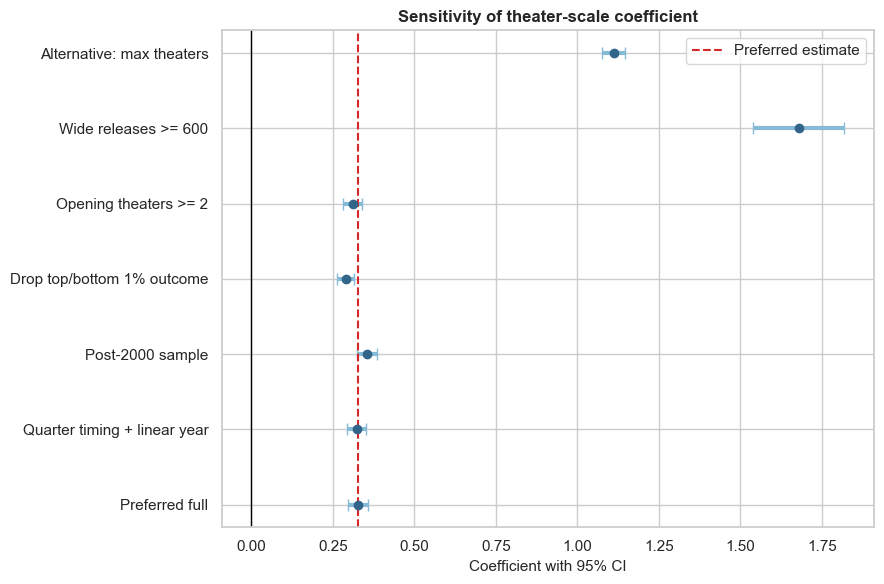

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_robust = robustness_table.copy()
plot_robust["err_low"] = plot_robust["coef"] - plot_robust["ci_low"]
plot_robust["err_high"] = plot_robust["ci_high"] - plot_robust["coef"]

ax.errorbar(
    x=plot_robust["coef"],
    y=plot_robust["check"],
    xerr=[plot_robust["err_low"], plot_robust["err_high"]],
    fmt="o",
    color="#33658A",
    ecolor="#86BBD8",
    elinewidth=3,
    capsize=4,
)
ax.axvline(preferred_beta, color="#D62828", linestyle="--", linewidth=1.5, label="Preferred estimate")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Sensitivity of theater-scale coefficient")
ax.set_xlabel("Coefficient with 95% CI")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()


The wide-release subset should be read carefully. Once the sample is restricted to movies that already opened widely, the remaining variation in theater count is much narrower and may represent a different distribution strategy. The estimate is therefore not directly comparable to the full-sample elasticity.


## 7. Heterogeneity: Do Effects Differ by Franchise Status or Budget?

The main specification assumes the theater-count association is the same for all movies. These interaction models test whether the relationship differs for franchise films or for higher-budget films.


In [15]:
interaction_formulas = {
    "Franchise interaction": (
        f"{y} ~ {x} * is_franchise + log_budget + C(release_month) + C(release_year) "
        "+ C(rating_group) + C(genre_grouped) + C(source_grouped) "
        "+ C(production_method_grouped) + C(creative_type_grouped) + running_time_minutes"
    ),
    "Budget interaction": (
        f"{y} ~ {x} * log_budget_centered + log_budget_centered + C(release_month) + C(release_year) "
        "+ C(rating_group) + C(genre_grouped) + C(source_grouped) "
        "+ C(production_method_grouped) + C(creative_type_grouped) + is_franchise + running_time_minutes"
    ),
}

interaction_models = {
    name: smf.ols(formula, data=model_data).fit(cov_type="HC3")
    for name, formula in interaction_formulas.items()
}

interaction_terms = {
    "Franchise interaction": [x, f"{x}:is_franchise", "is_franchise"],
    "Budget interaction": [x, f"{x}:log_budget_centered", "log_budget_centered"],
}

interaction_rows = []
for name, model in interaction_models.items():
    for term in interaction_terms[name]:
        ci = model.conf_int().loc[term]
        interaction_rows.append({
            "model": name,
            "term": term,
            "coef": model.params[term],
            "robust_se": model.bse[term],
            "p_value": model.pvalues[term],
            "ci_low": ci[0],
            "ci_high": ci[1],
        })

pd.DataFrame(interaction_rows).round(4)


,model,term,coef,robust_se,p_value,ci_low,ci_high
0,Franchise interaction,log_opening_theaters,0.3253,0.0152,0.0000,0.2955,0.3551
1,Franchise interaction,log_opening_theaters:is_franchise,0.0283,0.0486,0.5598,-0.0669,0.1236
2,Franchise interaction,is_franchise,0.5235,0.3857,0.1747,-0.2324,1.2793
3,Budget interaction,log_opening_theaters,0.3291,0.0162,0.0000,0.2975,0.3608
4,Budget interaction,log_opening_theaters:log_budget_centered,0.0051,0.0080,0.5251,-0.0106,0.0207
5,Budget interaction,log_budget_centered,0.3875,0.0560,0.0000,0.2777,0.4973


In [16]:
franchise_model = interaction_models["Franchise interaction"]
standalone_beta = franchise_model.params[x]
franchise_beta = standalone_beta + franchise_model.params[f"{x}:is_franchise"]

budget_model = interaction_models["Budget interaction"]
budget_interaction_p = budget_model.pvalues[f"{x}:log_budget_centered"]
franchise_interaction_p = franchise_model.pvalues[f"{x}:is_franchise"]

heterogeneity_text = f"""
### Heterogeneity interpretation

For standalone movies, the franchise-interaction model estimates a theater-count elasticity of **{standalone_beta:.3f}**.
For franchise movies, the implied elasticity is **{franchise_beta:.3f}**.
The interaction p-value is **{franchise_interaction_p:.3f}**, so this model does not provide strong evidence that the theater-count association differs by franchise status.

The budget interaction p-value is **{budget_interaction_p:.3f}**, so this model also does not provide strong evidence that the association differs systematically across budget levels.
"""

display(Markdown(heterogeneity_text))



### Heterogeneity interpretation

For standalone movies, the franchise-interaction model estimates a theater-count elasticity of **0.325**.
For franchise movies, the implied elasticity is **0.354**.
The interaction p-value is **0.560**, so this model does not provide strong evidence that the theater-count association differs by franchise status.

The budget interaction p-value is **0.525**, so this model also does not provide strong evidence that the association differs systematically across budget levels.


## 8. Diagnostics

These diagnostics assess whether the preferred model has obvious residual patterns, influential observations, or severe numeric multicollinearity among the main continuous controls.


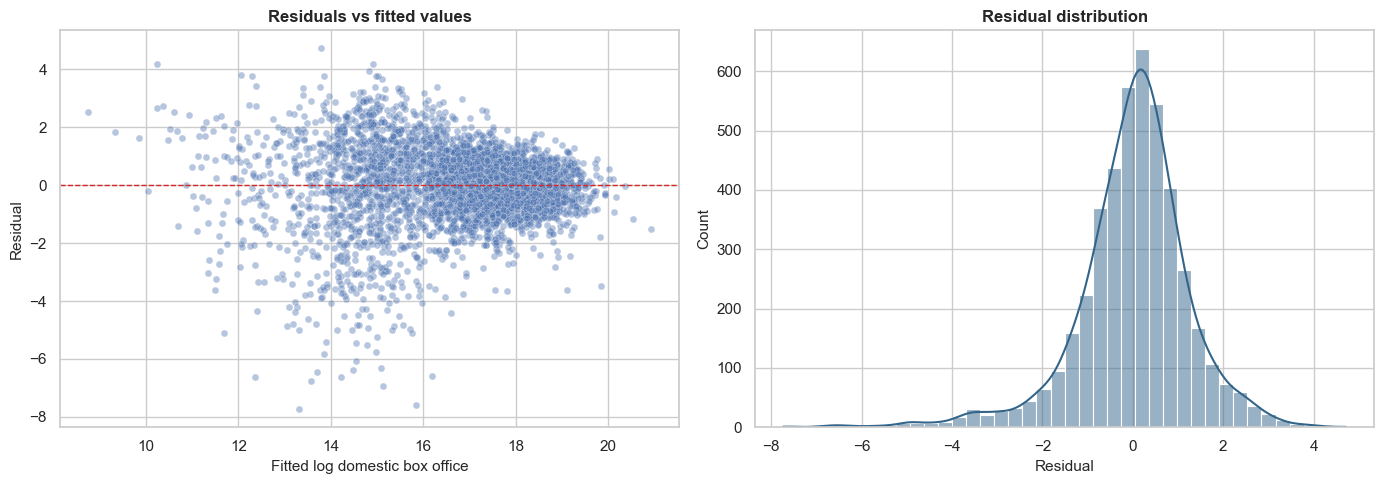

In [17]:
diagnostic_df = model_data.copy()
diagnostic_df["fitted"] = preferred.fittedvalues
diagnostic_df["residual"] = preferred.resid

def standardized_residuals(model):
    influence = model.get_influence()
    return influence.resid_studentized_internal

diagnostic_df["std_residual"] = standardized_residuals(preferred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=diagnostic_df, x="fitted", y="residual", alpha=0.4, s=25, ax=axes[0])
axes[0].axhline(0, color="#D62828", linestyle="--", linewidth=1)
axes[0].set_title("Residuals vs fitted values")
axes[0].set_xlabel("Fitted log domestic box office")
axes[0].set_ylabel("Residual")

sns.histplot(diagnostic_df["residual"], bins=40, kde=True, color="#33658A", ax=axes[1])
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()


In [18]:
influence = preferred.get_influence()
cooks = influence.cooks_distance[0]
diagnostic_df["cooks_distance"] = cooks

top_influence_cols = [
    col for col in [
        "movie_name", "release_year", "opening_theaters", "domestic_box_office_usd",
        "production_budget_usd", "fitted", "residual", "std_residual", "cooks_distance"
    ] if col in diagnostic_df.columns
]

diagnostic_df.sort_values("cooks_distance", ascending=False)[top_influence_cols].head(12)


,movie_name,release_year,opening_theaters,domestic_box_office_usd,production_budget_usd,fitted,residual,std_residual,cooks_distance
3050,Towering Inferno,1974,295.0,116000000.0,14000000,18.569101,5.755396e-13,0.000004,7.472932
3647,The Godfather,1972,6.0,136479994.0,7000000,18.731689,-4.547474e-13,-0.000001,0.166860
3268,Star Wars Ep. IV: A New Hope,1977,43.0,460998007.0,11000000,18.383832,1.565072e+00,1.745383,0.029804
3057,The Spy Who Loved Me,1977,194.0,46800000.0,14000000,19.226466,-1.565072e+00,-1.745383,0.029804
3623,Akira,1991,2.0,19585.0,8000000,14.798620,-4.916050e+00,-4.071314,0.017945
3937,After Hours,1985,1.0,193298906.0,4500000,14.916396,4.163353e+00,3.424120,0.010965
3174,Jaws,1975,409.0,273661595.0,12000000,20.929521,-1.502118e+00,-1.454223,0.010582
2063,Once Upon a Time in America,1984,894.0,5321508.0,30000000,19.109368,-3.622100e+00,-2.967131,0.007497
4281,The Rocky Horror Picture Show,1975,2.0,40564000.0,1200000,16.312640,1.205751e+00,1.171817,0.007026
3699,Twixt,2012,11.0,1996.0,7000000,14.211143,-6.611742e+00,-5.253721,0.006434


In [19]:
vif_vars = [
    "log_opening_theaters", "log_budget", "running_time_minutes",
    "is_franchise", "release_year"
]

vif_data = model_data[vif_vars].copy()
vif_data["intercept"] = 1.0
vif_table = pd.DataFrame({
    "variable": vif_data.columns,
    "vif": [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
})
vif_table.query("variable != 'intercept'").round(2)


,variable,vif
0,log_opening_theaters,1.73
1,log_budget,1.85
2,running_time_minutes,1.17
3,is_franchise,1.13
4,release_year,1.01


## 9. Thesis-Ready Summary

The regression results support the central empirical claim: theater availability is strongly and positively associated with domestic box office revenue, even after accounting for budget, release timing, genre, MPAA rating, production characteristics, franchise status, and running time.

The preferred model estimates an elasticity of roughly one-third. In practical terms, this means that doubling a movie's opening theater count is associated with about a 25% increase in domestic box office revenue, conditional on the included controls.

Additional findings:

- Production budget remains an important predictor after controlling for theater count.
- Franchise status is positively related to domestic box office in the preferred model, although the theater-count association does not appear meaningfully different for franchise and non-franchise movies.
- The result is robust to using release-quarter timing instead of month/year fixed effects, to restricting the sample to post-2000 films, and to excluding extreme domestic outcomes.
- Using maximum theater count produces a much larger association, but that variable should be treated as descriptive because it can be influenced by post-release performance.

Main limitation:

- These models estimate association, not causality. Wider releases are likely chosen for movies with higher expected demand, so unobserved factors may still explain part of the estimated relationship.


In [20]:
summary_text = f"""
### Final estimated statement for write-up

Using a sample of **{int(preferred.nobs):,} movies**, the preferred OLS model with HC3 robust standard errors estimates that the coefficient on `log_opening_theaters` is **{preferred_beta:.3f}**.
This corresponds to a **{preferred_doubling:.1f}%** increase in domestic box office revenue for a doubling of opening theater count, conditional on production budget, release month and year, MPAA rating, genre, source, production method, creative type, franchise status, and running time.
The estimate is statistically significant with p-value **{preferred_p:.3g}**.
"""

display(Markdown(summary_text))



### Final estimated statement for write-up

Using a sample of **4,480 movies**, the preferred OLS model with HC3 robust standard errors estimates that the coefficient on `log_opening_theaters` is **0.327**.
This corresponds to a **25.4%** increase in domestic box office revenue for a doubling of opening theater count, conditional on production budget, release month and year, MPAA rating, genre, source, production method, creative type, franchise status, and running time.
The estimate is statistically significant with p-value **5.32e-102**.
